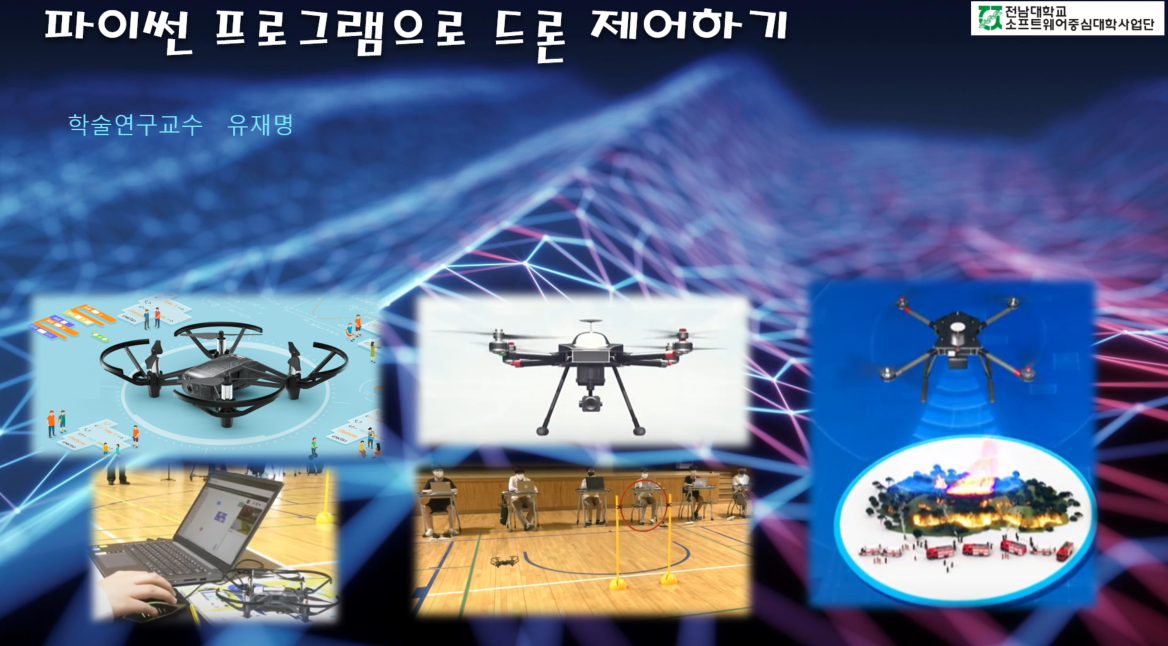  
<hr size=1 width=800px"/>  

# SOCKET 통신

## Socket 이란?
* 특정 포트를 이용하여 데이터를 송수신
* 서버: 서비스 주체
* 클라이언트: 서비스 사용자

## 프로토콜(Protocol)
* 그리스어의 <font color=red><b>Protokollen</b></font> 에서 유래
* Proto(맨처음) + Kollen(붙이다)
* 공증문서(외교문서)의 효력 부여를 위해 문서 맨 앞장에 붙이는 용지를 뜻함
* 국가간 공식행사에서 지켜야 할 일련의 규법
  
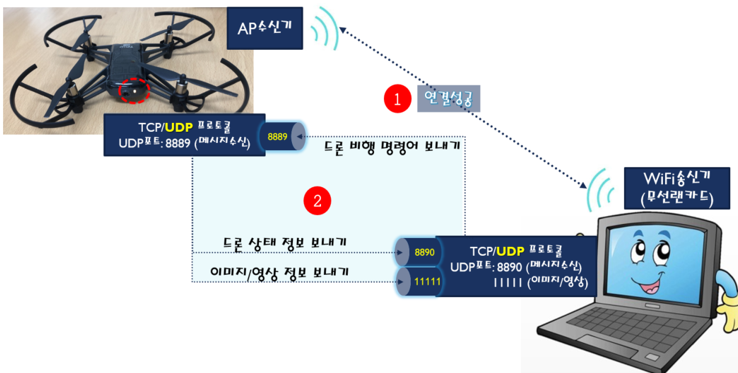  
<hr size=1 width=800px"/>    

# 통신방식(TCP, UDP)

## TCP(Transmission Control Protocol)
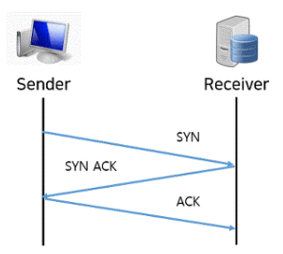    

## UDP(User Datagram Protocol)
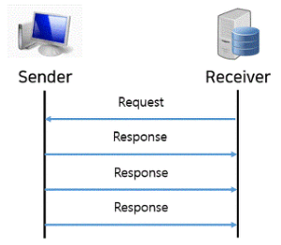  

## TCP, UDP 특징
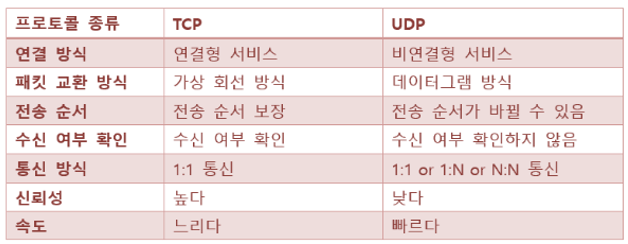

## 드론과 노트북(태블릿) 연결 상태
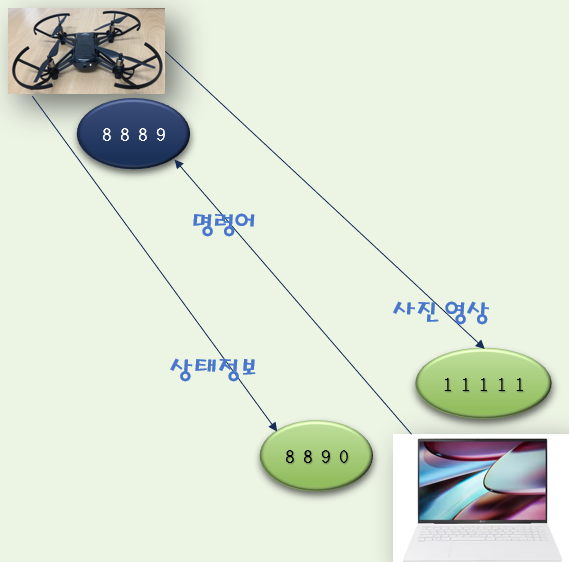  
<hr size=1 width=800px"/>  

## 사용중인 내컴퓨터의 IP확인
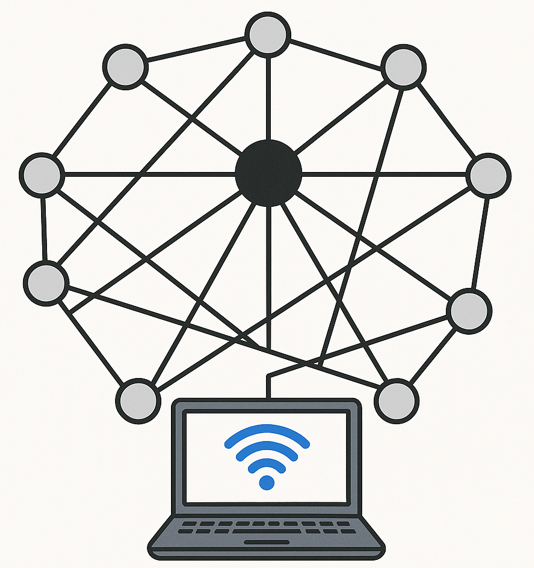  
<b>`아래 코드를 실행하시오`</b>

In [ ]:
!ipconfig

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  &ensp;
</div>

## 랜카드 종류
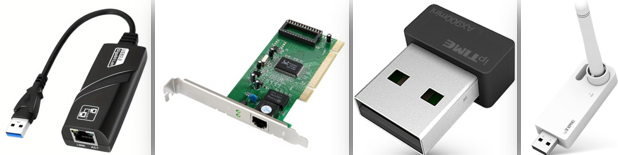  
<hr size=1 width=800px />  

## 네크워크 카드 
* NIC, Network Interface Card에 부여되는 고유 식별 번호
* 48비트: `00-00-00-00-00-00`
  > 앞 3바이트:OUI(Organizationally Unique Identifier), 제조사 식별  
  > 뒤 3바이트:NIC고유번호로 제조사 내부적으로 부여하는 일련번호
* 이더넷(유선), Wi-Fi(무선), 블루투스 등에서 사용
* 이더넷 프레임 구조

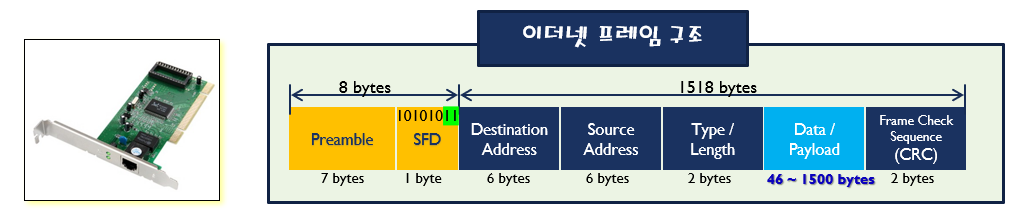  

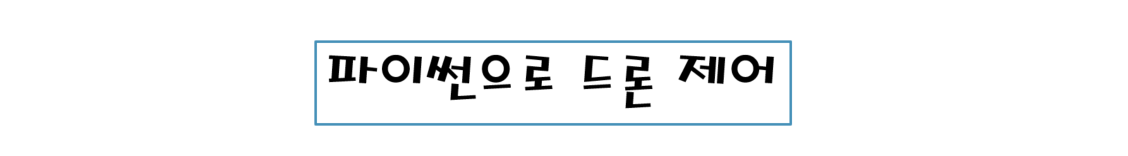

# DJI Drone 제공하는 API를 활용하기

## 사전준비사항
* API 모듈 추가
  > djitellopy 라이브러리 추가:  
  >  `pip install djitellopy`  
  > pip 업데이트:  
  >  `python -m pip install --upgrade pip`
  > 영상 라이브러리 추가:  
  >  `pip install opencv-python`
  > 
* <font color=red>[실습] 아래 기본 예시 코드를 실행하기</font>

```
## 매직쉘로 실행
## djitellopy 라이브러리 추가
!pip install djitellopy     
## pip 업데이트
!python -m pip install --upgrade pip 
## 영상 라이브러리 추가
!pip install opencv-python
```

## <a href="https://djitellopy.readthedocs.io/en/latest/tello/" target=_blank>DJITellopy 명령어 매뉴얼 URL</a>

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  &ensp;<b>미션패드 이해하기</b>
</div>

## 비젼인식 기술을 이용하여 미션패드 인식
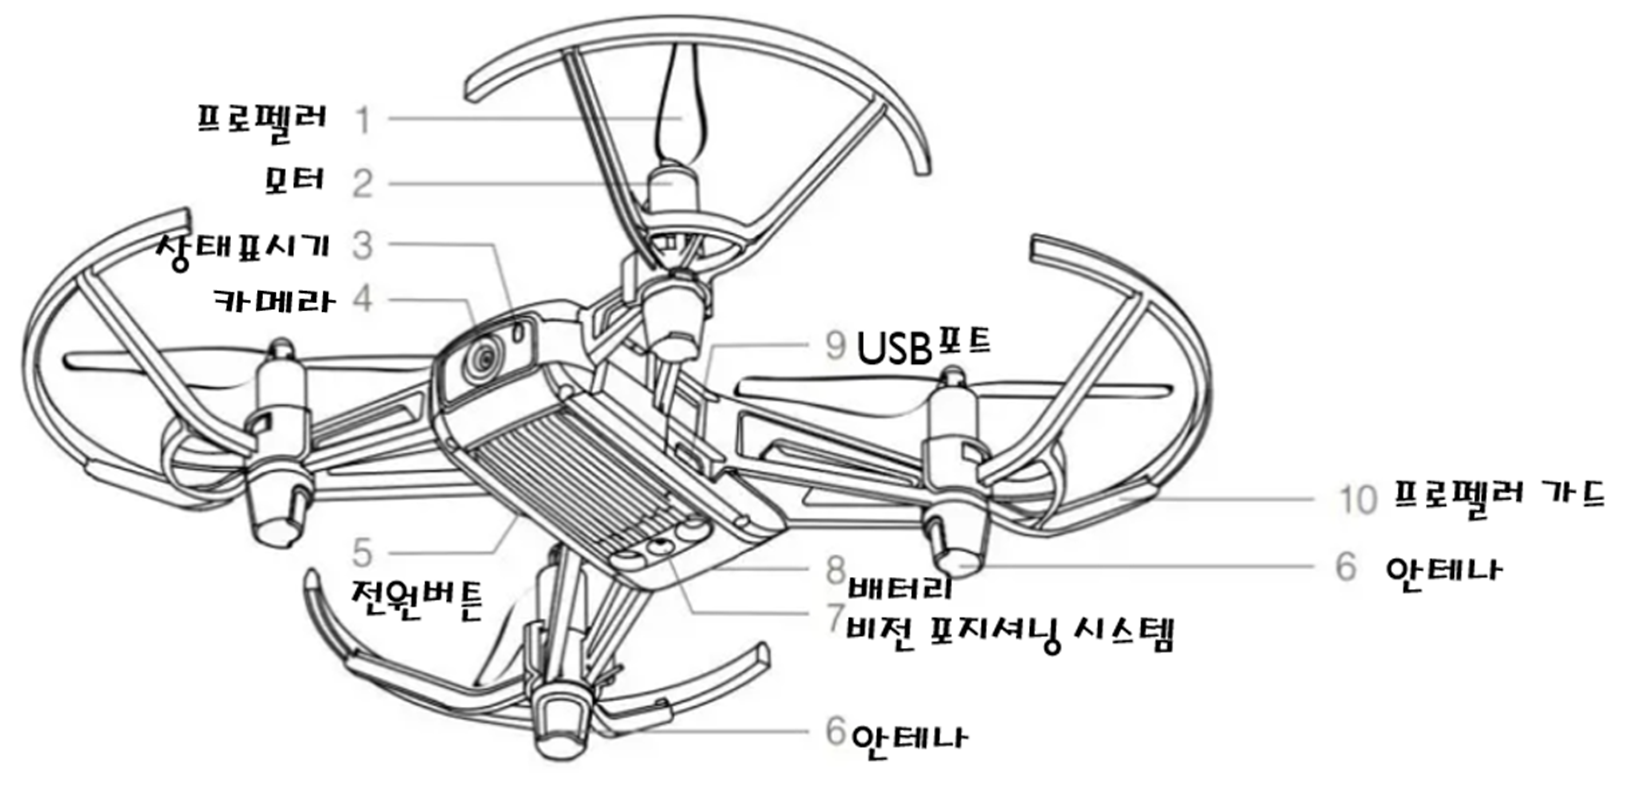<br>
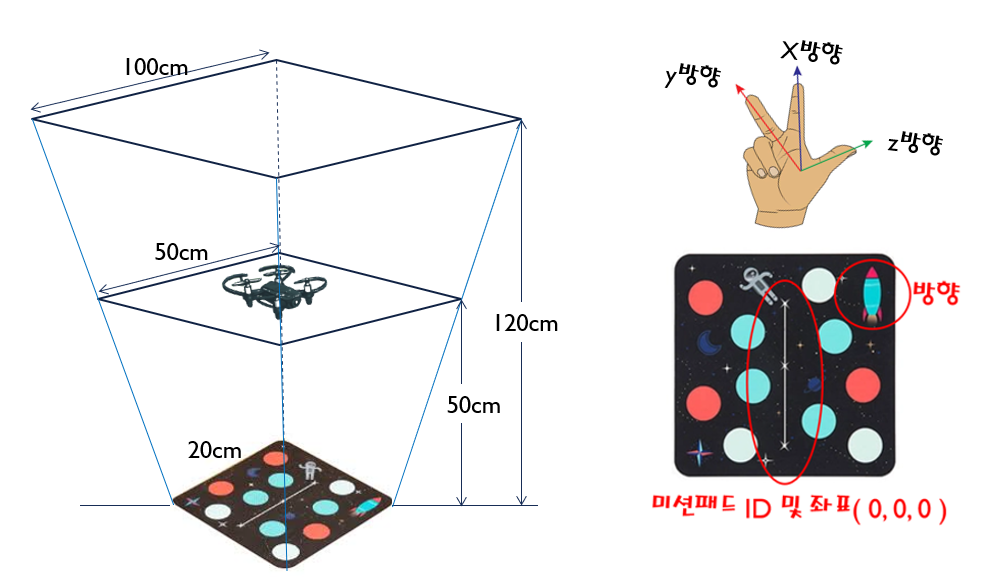<br>


<div style="background-color: #f9f9a9; padding: 1px 1px 1px 10px; border-radius: 1px;color:blue;text-align:left;">
  <h2>kill_process_using_port() 프로그램 종료하기 :: 시작전 반드시 1회 실행하기</h2>
</div><br>

```bash
# [참고자료] 명령프롬프트에서 UDP 8889포트 확인 및 프로세스 죽이기
# djitellopy에서 Tello() 객체가 생성될 때 로컬 포트 8889, 8890, 11111 포트를 생성함. 
!powershell -Command "netstat -anop udp | findstr 8889 | ForEach-Object { $ppp = ($_ -split '\s+')[4]; taskkill /pid $ppp /f }"     
```

In [ ]:
#udp(8890) 실행후 대기중인 프로세스를 종료
import subprocess
import os
import platform
    
def kill_process_using_port(port):
    if platform.system() == "Windows":
        cmd = f"netstat -ano | findstr :{port}"
    else:
        cmd = f"lsof -i :{port}"
    try:
        result = subprocess.check_output(cmd, shell=True, encoding='utf-8')
        #print(f"포트 {port} 사용 프로세스 목록")
        #print(result)
        pid=result.split()
        if platform.system() == "Windows":
            os.system(f"taskkill /PID {pid[3]} /F")
        else:
            os.system(f"kill -9 {pid[3]}")
        print(f"{port} -> {pid[3]} 강제 종료 완료")        
    except subprocess.CalledProcessError:
        print(f"포트 {port}를 사용하는 프로세스를 찾을 수 없음")
        
#프로그램 종료
kill_process_using_port(8890)

In [ ]:
!netstat -anop udp | findstr 8890

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  <b>미션패드 인식 : enable_mission_pads() -> set_mission_pad_detection_direction(number) -> get_mission_pad_id() ... -> disable_mission_pads()</b>
</div>

In [ ]:
from djitellopy import Tello
# create and connect
tello = Tello()
tello.connect()
#배터리 잔량 확인
print(f"Bat: {tello.get_battery()}%")

# 미션패드 활성: 아래쪽(0), 앞쪽(1), 자동(2)
tello.enable_mission_pads()
tello.set_mission_pad_detection_direction(0)  # backward 

tello.takeoff()

pad = 0

# 미션패드 인식 :: mid가  1이면 종료
while pad != 1:
    if pad == 3:        
        tello.rotate_clockwise(360)
        

    if pad == 5:
        tello.rotate_counter_clockwise(90)

    pad = tello.get_mission_pad_id()

# 미션패드 비활성 및 착륙
tello.disable_mission_pads()
tello.land()

#프로그램 종료
tello.end()
kill_process_using_port(8890)

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  <b>미션패드 대각선 비행 : go_xyz_speed_mid(x,y,z,speed,mid)</b><br><b>x,y,z</b>: -500 ~ 500 cm, <b>speed</b>: 10-100 cm/s, <b>mid</b>: 1~8
</div>

In [ ]:
from djitellopy import Tello
# create and connect
tello = Tello()
tello.connect()

# 미션패드 활성: 아래쪽(0), 앞쪽(1), 자동(2)
tello.enable_mission_pads()
tello.set_mission_pad_detection_direction(0)     

tello.takeoff()

# 미션패드 인식
pad = tello.get_mission_pad_id()

# 미션패드 ▽ 비행
tello.go_xyz_speed_mid(50,-50,100,30,1)
tello.go_xyz_speed_mid(50,50,100,30,1)
tello.go_xyz_speed_mid(0,0,100,30,1)

# 미션패드 비활성 및 착륙
tello.disable_mission_pads()
tello.land()

#프로그램 종료
tello.end()
kill_process_using_port(8890)

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  <b>미션패드 Jump 비행(1) : go_xyz_speed_yaw_mid(x,y,z,speed,yaw,mid1,mid2)</b><br><b>mid1에서 x,y,z</b>: -500 ~ 500 cm, <b>speed</b>: 10-100 cm/s, <b>mid2를 기준으로 yaw</b>:-360~360, <b>mid1,2</b>: 1~8
</div>

In [ ]:
from djitellopy import Tello
import time
# create and connect
tello = Tello()
tello.connect()

# 미션패드 활성: 아래쪽(0), 앞쪽(1), 자동(2)
tello.enable_mission_pads()
tello.set_mission_pad_detection_direction(0)                     

tello.takeoff()

# 미션패드 사이에서 Jump 비행
tello.go_xyz_speed_yaw_mid(0,-50,100,30,90,1,2)       
time.sleep(3)

# 미션패드 비활성 및 착륙
tello.disable_mission_pads()
tello.land()

#프로그램 종료
tello.end()
kill_process_using_port(8890)

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  <b>미션패드 Jump 비행(2) : go_xyz_speed_yaw_mid(x,y,z,speed,yaw,mid1,mid2)</b><br><b>2사람씩 짝을 이루어 4개의 미션패드 이동하기</b>
</div>

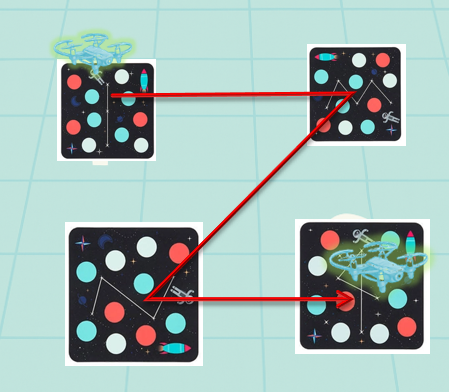

In [ ]:
from djitellopy import Tello
import time
# create and connect
tello = Tello()
tello.connect()

# 미션패드 활성: 아래쪽(0), 앞쪽(1), 자동(2)
tello.enable_mission_pads()
tello.set_mission_pad_detection_direction(0)  # backward detection only

tello.takeoff()

# 4개의 미션패드 사이 비행
# 아래에 코드를 추가하시오. (새 미션패드로 이동 > 1초 대기(time.sleep(1) > 다음 미션패드로 이동) 



# 미션패드 비활성 및 착륙
tello.disable_mission_pads()
tello.land()

#프로그램 종료
tello.end()
kill_process_using_port(8890)

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  <b>미션패드 곡선비행 : curve_xyz_speed_mid(x1,y1,z1,x2,y2,z2,speed,mid)</b><br><b>x,y,z</b>: -500~500 cm, <b>speed</b>: 10~60 cm/s, <b>mid</b>: 1~8
</div>

In [ ]:
from djitellopy import Tello
import time
# create and connect
tello = Tello()
tello.connect()

# 미션패드 활성: 아래쪽(0), 앞쪽(1), 자동(2)
tello.enable_mission_pads()
tello.set_mission_pad_detection_direction(0)                      

tello.takeoff()

#고도 준비
height = 70 - tello.get_height()
if height>=20:
    tello.move("up", height)

# 나선형으로 돌리기 비행
tello.curve_xyz_speed_mid(60,0,110,-60,0,110,20,1)     
tello.curve_xyz_speed_mid(0,0,70,0,0,120,20,1) # 가능하도록 조정 필요  
time.sleep(1)

# 미션패드 비활성 및 착륙
tello.disable_mission_pads()
tello.land()

#프로그램 종료
tello.end()
kill_process_using_port(8890)

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  <b>(미션1) 미션패드 1번에서 3번까지 이동하기</b><br>
  - 이동명령: <font color=red> <b>move</b>(<b>'direction'</b>,<b>x</b>) </font>  => <b>direction</b>: forward, back, right,left,up, down, <b>x</b>: 20 ~ 500 cm <br>
  - 고도 측정: <font color=red><b>get_height()</b></font><br>
  - 미션패드 확인: <font color=red><b>get_mission_pad_id()</b></font><br>
  - 비행속도 설정: <font color=red><b>set_speed(x)</b></font>  => <b>x</b>: 10 ~ 100 cm/s 
</div>

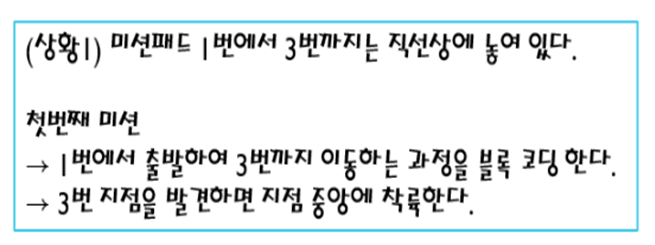  
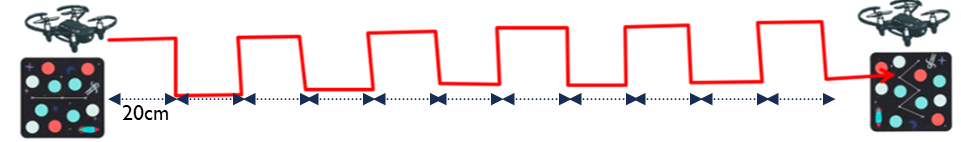  

<font color=blue><b>(필수 조건)</b></font><br>
1. <b>비행 고도</b>: <font color=red><b>100 cm</b></font>으로 맞출 것
2. <b>비행 속도</b>: <font color=red><b>30 cm/s</b></font>로 진행할 것
3. <b>이동 간격</b>: <font color=red><b>20 cm</b></font>로 진행할 것


In [ ]:
from djitellopy import Tello
import time
# create and connect
tello = Tello()
tello.connect()

# 미션패드 활성: 아래쪽(0), 앞쪽(1), 자동(2)
tello.enable_mission_pads()
tello.set_mission_pad_detection_direction(0)            

tello.takeoff()

# 상황1(첫번째 미션)
# 아래에 코드를 추가하시오. 


# 미션패드 비활성 및 착륙
tello.disable_mission_pads()
tello.land()

#프로그램 종료
tello.end()
kill_process_using_port(8890)

## 참고할 코드
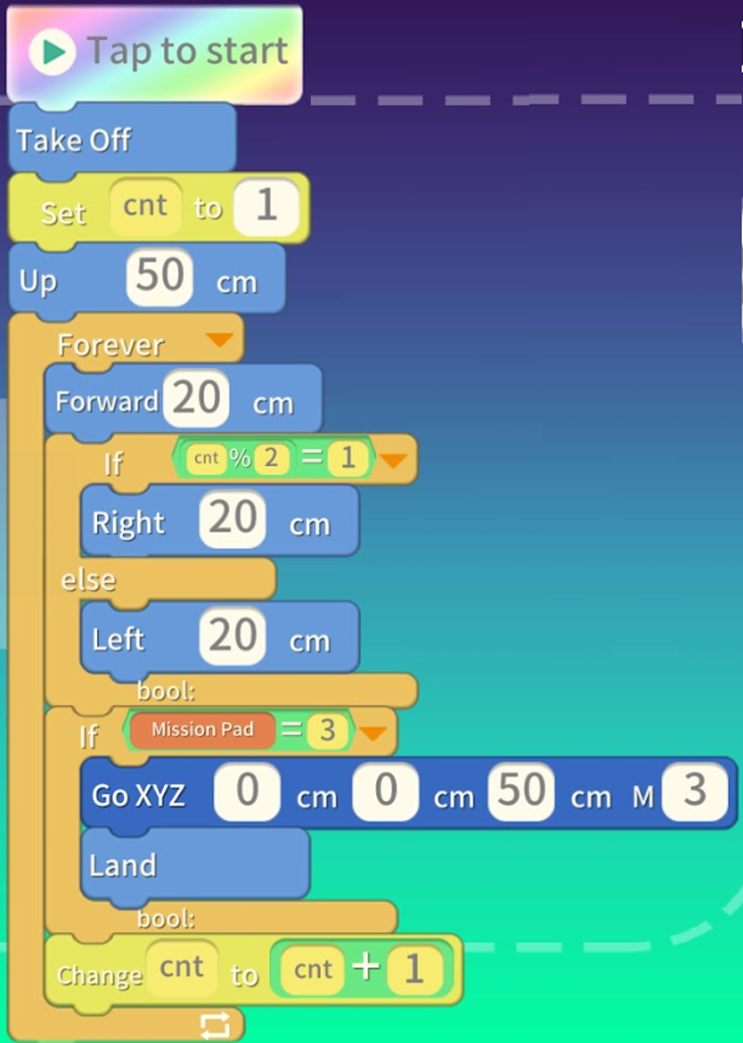

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  <b>&ensp;</b><br>
  &ensp;
</div>

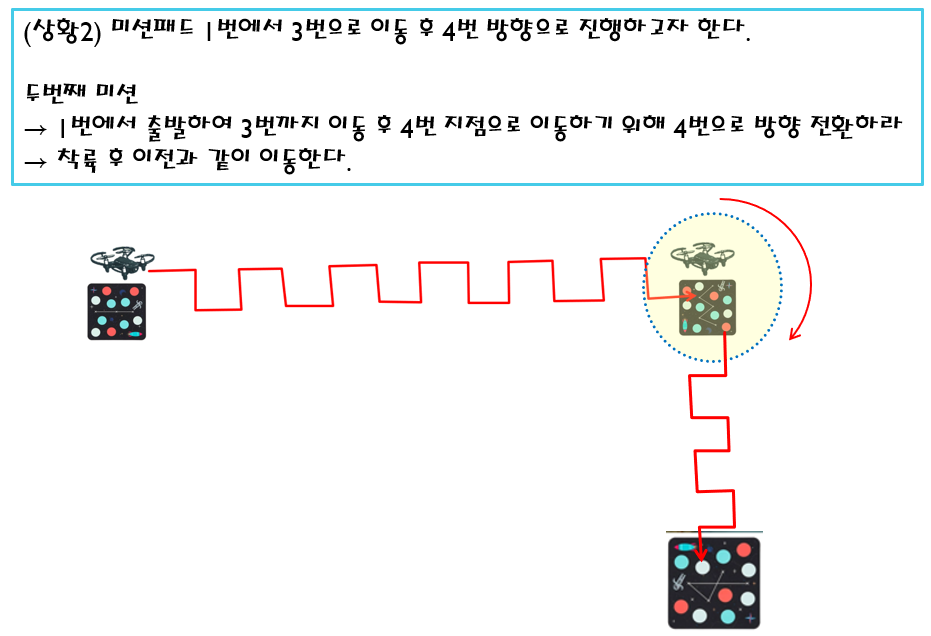

In [ ]:
from djitellopy import Tello
import time
# create and connect
tello = Tello()
tello.connect()

# 미션패드 활성: 아래쪽(0), 앞쪽(1), 자동(2)
tello.enable_mission_pads()
tello.set_mission_pad_detection_direction(0)  # backward detection only

tello.takeoff()

# 상황2(두번째 미션)
# 아래에 코드를 추가하시오. 


# 미션패드 비활성 및 착륙
tello.disable_mission_pads()
tello.land()

#프로그램 종료
tello.end()
kill_process_using_port(8890)

# 중요 자료
* <a href="https://djitellopy.readthedocs.io/en/latest/tello/">DJITellopy 매뉴얼 보기</a>
* <a href="https://github.com/damiafuentes/DJITelloPy">DJITellopy 파이썬코드 오픈 소스 보기</a>


## ✈️ 비행 제어 명령어

<span style="display:inline-block;position:left;">

| 메서드                                                   | 설명                                  |                                               |
| ----------------------------------------------------- | ----------------------------------- | --------------------------------------------- |
| `connect()`                                           | 드론과 연결                              |                                               |
| `takeoff()`                                           | 이륙                                  |                                               |
| `land()`                                              | 착륙                                  |                                               |
| `emergency()`                                         | 비상 정지 (모터 즉시 정지)                    |                                               |
| `move_up(x)` / `move_down(x)`                         | x(20 ~ 500 cm) 만큼 상승 / 하강                    |                                               |
| `move_left(x)` / `move_right(x)`                      | x(20 ~ 500 cm) 만큼 좌 / 우 이동                   |                                               |
| `move_forward(x)` / `move_back(x)`                    | x(20 ~ 500 cm) 만큼 전진 / 후진                    |                                               |
| `rotate_clockwise(x)` / `rotate_counter_clockwise(x)` | x(1 ~ 360 도) 만큼 시계 / 반시계 방향 회전              |                                               |
| `flip(direction)`                                     | 지정된 방향으로 플립 (예: 'l', 'r', 'f', 'b') |                                               |
| `go_xyz_speed(x, y, z, speed)`                        | 지정된 좌표로 이동 (cm 단위)<br> x,y,z : -500 ~ 500<br>speed: 10 ~ 100  |                                               |
| `curve_xyz_speed(...)`                                | 곡선 경로로 이동<br>x1,y1,z1,x2,y2,z2: -500 ~ 500<br>speed: 10 ~ 60 |                                               |
| `send_rc_control(lr, fb, ud, yaw)`                    | 실시간 RC 제어 (각 방향 속도 설정)              | 조이스틱 활용 |

</span>


<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  드론 비행 상태 정보
</div>

In [ ]:
# djitellopy 모듈 예시
from djitellopy import Tello
import time
tello = Tello(host='192.168.10.1')
tello.connect()
print("■ 드론 상태정보")
print(f"드론상태: {tello.query_active()}")
print(f"Bat: {tello.get_battery()}%")
print(f"SDK버전: {tello.query_sdk_version()}")
print(f"제품번호(SD): {tello.query_serial_number()}")
print(f"현재 상태 dict: {tello.get_current_state()}")
print(f"bat(key) 상태: {tello.get_state_field('bat')}%")
print("■ 드론 비행 상태정보")
tello.takeoff()
print(f"Bat: {tello.get_battery()}%")
print(f"높이: {tello.get_height()}")
print(f"pitch,roll,yaw: {tello.query_attitude()}")                     
print(f"비행거리 tof: {tello.get_distance_tof()}")
print(f"비행시간 tof: {tello.get_flight_time()}")

tello.land()

#프로그램 종료
tello.end()
kill_process_using_port(8890)